In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import yaml
from scipy.stats import wasserstein_distance

selection = "ATLAS"
sample_path = f"Models_Extrapolation_{selection}_ver2/samples"
dataset_path = f"Final_Dataset_{selection}"

N_ENSEMBLE = 10

context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

In [4]:
# Load Reweight Events
mc_sr_reweight_events = pd.read_parquet(f"{sample_path}/MC_SR_reweighted.parquet")

# Load Generate Events

mc_sr_generate_dfs = []
for i in range(N_ENSEMBLE):
    df = pd.read_parquet(f"{sample_path}/MC_SR_Generate_ens{i}.parquet")
    mc_sr_generate_dfs.append(df)


data_sr_events = pd.read_parquet(f"{dataset_path}/DATA_SR_clean.parquet")

print(f"Loaded {len(data_sr_events)} Data events")
print(f"Loaded {len(mc_sr_reweight_events)} Reweight events")
print(f"Loaded {len(mc_sr_generate_dfs[0])} Generate events")

Loaded 188757 Data events
Loaded 528846 Reweight events
Loaded 528846 Generate events


Data events shape: (188757, 8)
Reweighted events shape: (528846, 40)
Generated events shapes: [(528846, 9), (528846, 9), (528846, 9), (528846, 9), (528846, 9), (528846, 9), (528846, 9), (528846, 9), (528846, 9), (528846, 9)]
 == Check W1 ==
Data W1: 0.0


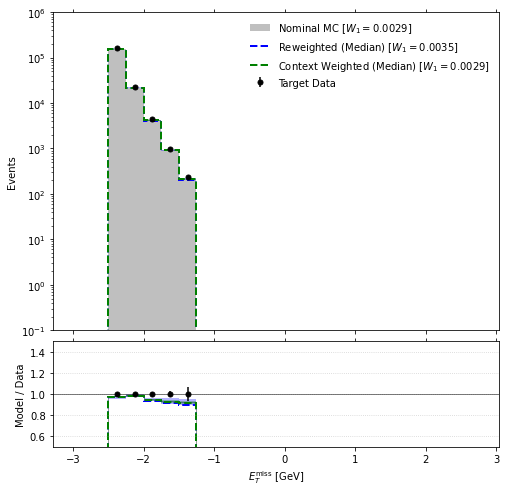

 == Check W1 ==
Data W1: 0.0


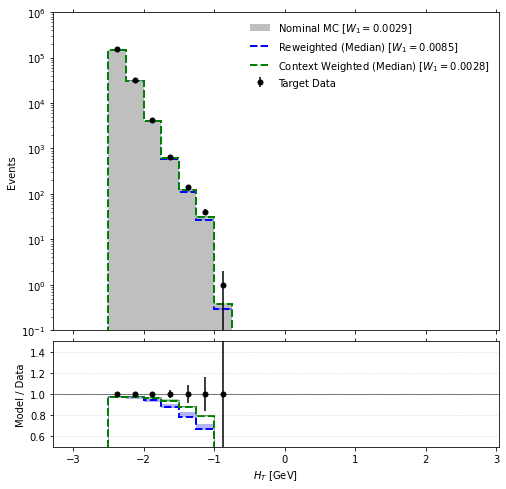

 == Check W1 ==
Data W1: 0.0


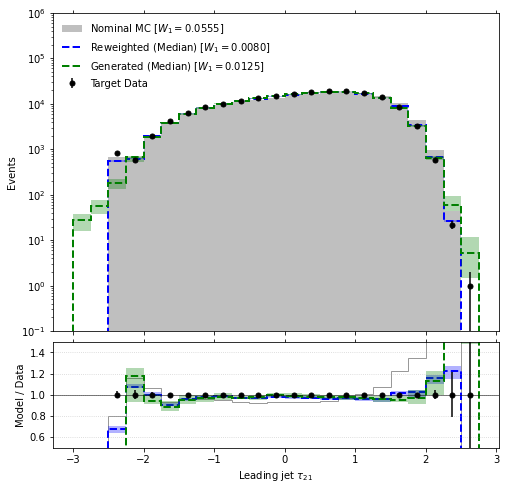

 == Check W1 ==
Data W1: 0.0


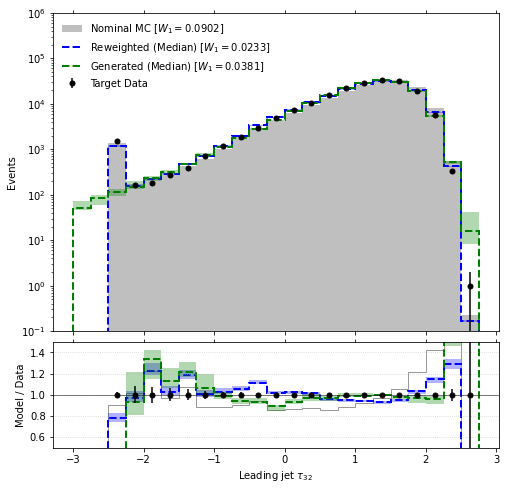

 == Check W1 ==
Data W1: 0.0


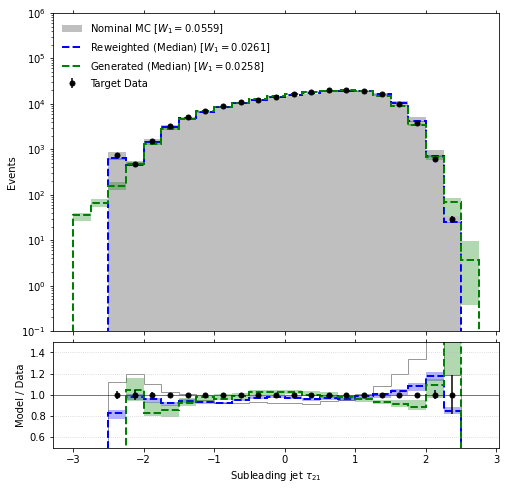

 == Check W1 ==
Data W1: 0.0


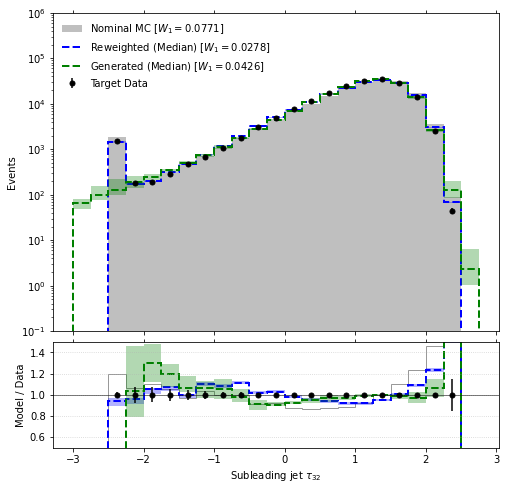

 == Check W1 ==
Data W1: 0.0


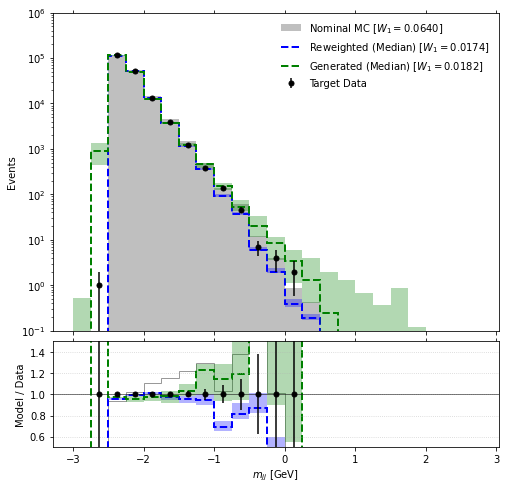

In [5]:
def plot_context_events(data_events, reweight_events, generate_events):
    print(f"Data events shape: {data_events.shape}")
    print(f"Reweighted events shape: {reweight_events.shape}")
    print(f"Generated events shapes: {[gen_events.shape for gen_events in generate_events]}")

    bins = np.arange(-3.0, 3.0, 0.25)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    for var in context_vars + features_vars:
        # Create a figure with two vertically stacked panels
        fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(8, 8), 
            gridspec_kw={'height_ratios': [3, 1]}, 
            sharex=True
        )
        
        # Remove horizontal space between axes
        fig.subplots_adjust(hspace=0.05)

        # ==========================================
        # TARGET DATA (Calculated once for both panels)
        # ==========================================
        data_arr = data_events[var].to_numpy()
        counts_data, _ = np.histogram(data_arr, bins=bins)
        data_errors = np.sqrt(counts_data)
        std_data = np.std(data_arr)
        w1_data = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=counts_data)/std_data

        print(" == Check W1 ==")
        print("Data W1:", w1_data)
        
        # Top panel: Data
        ax1.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)

        # Bottom panel: Data reference at 1.0
        # Safe division to get fractional errors for the ratio plot
        valid = counts_data > 0
        data_ratio_err = np.zeros_like(counts_data, dtype=float)
        data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
        
        ax2.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), yerr=data_ratio_err[valid], fmt='ko', zorder=10, capsize=0, markersize=5)
        ax2.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # ==========================================
        # NOMINAL MC
        # ==========================================
        mc_reweight_arr = reweight_events[var].to_numpy()
        nominal_weights = reweight_events['final_weight'].to_numpy()
        
        counts_nom, _ = np.histogram(mc_reweight_arr, bins=bins, weights=nominal_weights)
        w1_nom = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=counts_nom)/std_data
        ax1.stairs(counts_nom, bins, fill=True, color="grey", alpha=0.5, label=f'Nominal MC [$W_1 = {w1_nom:.4f}$]')
        
        # Nominal ratio
        ratio_nom = np.divide(counts_nom, counts_data, out=np.full_like(counts_nom, np.nan, dtype=float), where=valid)
        ax2.stairs(ratio_nom, bins, color="grey", alpha=0.8)

        # ==========================================
        # REWEIGHT EVENTS
        # ==========================================
        rw_binned = [] 
        for i in range(N_ENSEMBLE):
            rw_weight = reweight_events[f'reweight_weights_ens{i}'].to_numpy()
            counts, _ = np.histogram(mc_reweight_arr, bins=bins, weights=nominal_weights * rw_weight)
            rw_binned.append(counts)
            
        rw_median = np.median(rw_binned, axis=0)
        rw_lower = np.percentile(rw_binned, 2.5, axis=0)
        rw_upper = np.percentile(rw_binned, 97.5, axis=0)
        
        rw_lower_clip = np.clip(rw_lower, 1e-3, None)
        rw_median_clip = np.clip(rw_median, 1e-3, None)

        w1_rw = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=rw_median)/std_data
        # Top panel
        ax1.stairs(rw_median_clip, bins, color="blue", linewidth=2, linestyle='--', label=f'Reweighted (Median) [$W_1 = {w1_rw:.4f}$]')
        ax1.stairs(rw_upper, bins, baseline=rw_lower_clip, fill=True, color='blue', alpha=0.3)

        # Bottom panel
        rw_ratio_med = np.divide(rw_median, counts_data, out=np.full_like(rw_median, np.nan, dtype=float), where=valid)
        rw_ratio_low = np.divide(rw_lower, counts_data, out=np.full_like(rw_lower, np.nan, dtype=float), where=valid)
        rw_ratio_up = np.divide(rw_upper, counts_data, out=np.full_like(rw_upper, np.nan, dtype=float), where=valid)
        
        ax2.stairs(rw_ratio_med, bins, color="blue", linewidth=2, linestyle='--')
        ax2.stairs(rw_ratio_up, bins, baseline=rw_ratio_low, fill=True, color='blue', alpha=0.3)

        # ==========================================
        # CONTEXT WEIGHTS
        # ==========================================
        cw_binned = [] 
        for i in range(N_ENSEMBLE):
            cw_weight = generate_events[i]['total_weight'].to_numpy() 
            cw_arr = generate_events[i][var].to_numpy() 
            counts, _ = np.histogram(cw_arr, bins=bins, weights=cw_weight)
            cw_binned.append(counts)
            
        cw_median = np.median(cw_binned, axis=0)
        cw_lower = np.percentile(cw_binned, 2.5, axis=0)
        cw_upper = np.percentile(cw_binned, 97.5, axis=0)

        cw_lower_clip = np.clip(cw_lower, 1e-3, None)
        cw_median_clip = np.clip(cw_median, 1e-3, None)

        w1_cw = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=cw_median)/std_data
        # Top panel
        if var in context_vars:
            label_gen = 'Context Weighted (Median)'
        else:
            label_gen = 'Generated (Median)'
        ax1.stairs(cw_median_clip, bins, color="green", linewidth=2, linestyle='--', label=f'{label_gen} [$W_1 = {w1_cw:.4f}$]')
        ax1.stairs(cw_upper, bins, baseline=cw_lower_clip, fill=True, color='green', alpha=0.3)

        # Bottom panel
        cw_ratio_med = np.divide(cw_median, counts_data, out=np.full_like(cw_median, np.nan, dtype=float), where=valid)
        cw_ratio_low = np.divide(cw_lower, counts_data, out=np.full_like(cw_lower, np.nan, dtype=float), where=valid)
        cw_ratio_up = np.divide(cw_upper, counts_data, out=np.full_like(cw_upper, np.nan, dtype=float), where=valid)

        ax2.stairs(cw_ratio_med, bins, color="green", linewidth=2, linestyle='--')
        ax2.stairs(cw_ratio_up, bins, baseline=cw_ratio_low, fill=True, color='green', alpha=0.3)

        # ==========================================
        # PLOT FORMATTING
        # ==========================================
        # Top Panel
        ax1.set_yscale('log')
        ax1.set_ylim(0.1, 1e6)
        ax1.set_ylabel('Events')
        ax1.legend(frameon=False)
        ax1.tick_params(axis='x', which='both', bottom=True, top=True, labelbottom=False)

        # Bottom Panel (Ratio)
        ax2.set_ylabel('Model / Data')
        # Adjust these limits based on how wild your ratios get. 0.5 to 1.5 is standard.
        ax2.set_ylim(0.5, 1.5) 
        ax2.set_xlabel(pretty_labels.get(var, var))
        ax2.tick_params(axis='x', which='both', bottom=True, top=True)
        ax2.grid(True, axis='y', linestyle=':', alpha=0.6)

        plt.show()
plot_context_events(data_sr_events, mc_sr_reweight_events, mc_sr_generate_dfs)

In [6]:
# Run Classifier Ensemble
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier


def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, classifier_runs=20):
    
    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    n_features = set_1.shape[1]
    
    # ---------- Logging ----------
    print(f"\nWorking on {code}...")
    print(f"      Total Events - Set 1: {set_1.shape[0]}, Set 2: {set_2.shape[0]}")
    
    aucs_list = []

    for i in range(int(classifier_runs)):
        if i < 17:
            continue
        print(f"\nClassifier run {i+1} of {classifier_runs}.")
        local_id = f"{code}_run{i}"
        
        # 2 & 4. SPLIT INSIDE THE LOOP (Flat 20% Test Size)
        # random_state=i ensures a unique train/test combination for each of the 20 runs.
        trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(
            set_1, w_1, test_size=0.2, random_state=i
        )
        trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(
            set_2, w_2, test_size=0.2, random_state=i
        )

        # 1. APPLY WEIGHTS AS IS
        # No scaling/normalization applied here to preserve Anomaly Detection physics.
        input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
        input_y_train = np.concatenate([
            np.zeros(trainset_1.shape[0]),
            np.ones(trainset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw training weights directly
        input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

        input_x_test = np.concatenate([testset_1, testset_2], axis=0)
        input_y_test = np.concatenate([
            np.zeros(testset_1.shape[0]),
            np.ones(testset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw testing weights directly
        combined_test_weights = np.concatenate([wtest_1, wtest_2])

        if i == 0:
            print(f"      Train shapes: X:{input_x_train.shape}, y:{input_y_train.shape}, w:{input_w_train.shape}")
            print(f"      Test shapes: X:{input_x_test.shape}, y:{input_y_test.shape}")
                
        # 3. NO SCALING APPLIED (scale_data=False)
        NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
                        learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
        if i == 0: print("Using device:", NN.device)
        
        NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
                 model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=i, outdir=save_dir)

        # 4. EVALUATION
        scores = NN.evaluation(input_x_test)
        auc = roc_auc_score(input_y_test, scores, sample_weight=combined_test_weights)
        
        if auc < 0.5:
            auc = 1.0 - auc  # symmetry adjustment
            
        aucs_list.append(auc)
        print(f"   --> AUC: {auc:.4f}")
    
    # ---------- Save results ----------
    os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
    np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

    print("\n--- Summary for", code, "---")
    print(f"Median AUC:       {np.median(aucs_list):.4f}")
    print(f"16th percentile:  {np.percentile(aucs_list, 16):.4f}")
    print(f"84th percentile:  {np.percentile(aucs_list, 84):.4f}")
    print("Done.\n")

In [7]:
device = torch.device("cpu")
print("Device:", device)
config_path = "/home/aegis/Titan1/NRAD/data/configs"
eval_dir = f"Eval_CWoLa_SR_{selection}_ver2"
os.makedirs(eval_dir, exist_ok=True)
with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params = yaml.safe_load(stream)

train_nom = False
train_rw = False
train_gen = False

Device: cpu


In [8]:
if train_nom:
    print("CWoLa SR: Data vs Nominal")

    features_data = data_sr_events[features_vars].values
    w_data = np.ones(len(features_data))
    features_nom = mc_sr_reweight_events[features_vars].values
    w_nom = mc_sr_reweight_events["final_weight"].values
    run_eval(features_data, features_nom, code=f"Data_vs_Nom_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_data, w_2=w_nom)

In [9]:
if train_rw:
    print(f"CWoLa SR: Data vs Reweight (Median of {N_ENSEMBLE} models)")

    features_rw = mc_sr_reweight_events[features_vars].values
    nominal_w = mc_sr_reweight_events["final_weight"].values

    rw_ensemble_weights = [mc_sr_reweight_events[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
    rw_median = np.median(rw_ensemble_weights, axis=0)
    w_rw_median = nominal_w * rw_median

    run_eval(
        features_data, features_rw, 
        code=f"Data_vs_Reweight_Median_{selection}", 
        save_dir=eval_dir, classifier_params=params, device=device, 
        w_1=w_data, w_2=w_rw_median
    )

In [10]:
if train_gen:
    print(f"CWoLa CR: Data vs Generate (Combined {N_ENSEMBLE} models)")

    features_gen_combined = np.vstack([df[features_vars].values for df in mc_sr_generate_dfs])

    w_gen_combined = np.concatenate([df['total_weight'].values for df in mc_sr_generate_dfs]) / N_ENSEMBLE

    run_eval(
        features_data, features_gen_combined, 
        code=f"Data_vs_Generate_Combined_{selection}", 
        save_dir=eval_dir, classifier_params=params, device=device, 
        w_1=w_data, w_2=w_gen_combined
    )

In [11]:
from sklearn.model_selection import KFold

def run_kfold_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, n_splits=5, random_state=42):
    
    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    n_features = set_1.shape[1]
    
    # Initialize empty arrays to hold the Out-Of-Fold (OOF) predictions
    oof_scores_1 = np.zeros(set_1.shape[0])
    oof_scores_2 = np.zeros(set_2.shape[0])
    
    # Create identical k-fold splitters for both datasets
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    print(f"\nWorking on {code} with {n_splits}-Fold CV...")
    print(f"      Total Events - Set 1: {set_1.shape[0]}, Set 2: {set_2.shape[0]}")
    
    # We zip the splits so we combine the i-th fold of set_1 with the i-th fold of set_2
    for fold, ((train_idx1, test_idx1), (train_idx2, test_idx2)) in enumerate(zip(kf.split(set_1), kf.split(set_2))):
        print(f"\n   --- Fold {fold + 1} of {n_splits} ---")
        
        # 1. Build Training Set (k-1 folds)
        input_x_train = np.concatenate([set_1[train_idx1], set_2[train_idx2]], axis=0)
        input_y_train = np.concatenate([
            np.zeros(len(train_idx1)),
            np.ones(len(train_idx2))
        ]).reshape(-1, 1)
        input_w_train = np.concatenate([w_1[train_idx1], w_2[train_idx2]], axis=0).reshape(-1, 1)
        
        # 2. Build Testing Set (1 hold-out fold)
        input_x_test_1 = set_1[test_idx1]
        input_x_test_2 = set_2[test_idx2]
        
        # 3. Train Model
        local_id = f"{code}_fold{fold+1}"
        NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
                        learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
        NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
                 model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=random_state+fold, outdir=save_dir)

        # 4. Score ONLY the hold-out test sets
        # (.flatten() ensures it fits nicely back into our 1D OOF arrays)
        scores_test_1 = NN.evaluation(input_x_test_1).flatten()
        scores_test_2 = NN.evaluation(input_x_test_2).flatten()
        
        # 5. Insert scores into the original indexing position
        oof_scores_1[test_idx1] = scores_test_1
        oof_scores_2[test_idx2] = scores_test_2

    # 6. Global Evaluation
    # Now that every event has a score, we calculate the global AUC
    combined_y = np.concatenate([np.zeros(set_1.shape[0]), np.ones(set_2.shape[0])])
    combined_scores = np.concatenate([oof_scores_1, oof_scores_2])
    combined_w = np.concatenate([w_1, w_2])
    
    global_auc = roc_auc_score(combined_y, combined_scores, sample_weight=combined_w)
    
    # Symmetry adjustment if the classifier learns the labels backwards
    if global_auc < 0.5:
        global_auc = 1.0 - global_auc 
        
    print(f"\n--- Summary for {code} ---")
    print(f"Global OOF AUC: {global_auc:.4f}\n")
    
    # Return the full score arrays in the exact order of the original datasets
    return oof_scores_1, oof_scores_2


K_Fold_dir = f"{eval_dir}/kfold"

In [12]:

# --- 1. CWoLa SR: Data vs Nominal ---
print("CWoLa SR: Data vs Nominal")
features_data = data_sr_events[features_vars].values
w_data = np.ones(len(features_data))
features_nom = mc_sr_reweight_events[features_vars].values
w_nom = mc_sr_reweight_events["final_weight"].values

scores_data, scores_nom = run_kfold_eval(
    features_data, features_nom, 
    code=f"Data_vs_Nom_{selection}", 
    save_dir=K_Fold_dir, classifier_params=params, device=device, 
    w_1=w_data, w_2=w_nom, n_splits=5
)

data_sr_events['score_vs_nominal'] = scores_data
mc_sr_reweight_events['score_vs_data'] = scores_nom

CWoLa SR: Data vs Nominal

Working on Data_vs_Nom_ATLAS with 5-Fold CV...
      Total Events - Set 1: 188757, Set 2: 528846

   --- Fold 1 of 5 ---


 34%|===       | 17/50 [02:50<05:31, 10.04s/it]



   --- Fold 2 of 5 ---


 22%|==        | 11/50 [01:56<06:54, 10.63s/it]



   --- Fold 3 of 5 ---


...


   --- Fold 4 of 5 ---


 18%|=>        | 9/50 [01:33<07:04, 10.36s/it]



   --- Fold 5 of 5 ---


 24%|==        | 12/50 [02:07<06:45, 10.67s/it]



--- Summary for Data_vs_Nom_ATLAS ---
Global OOF AUC: 0.5614



In [13]:
# --- 2. CWoLa SR: Data vs Reweight ---
print(f"CWoLa SR: Data vs Reweight")
features_rw = mc_sr_reweight_events[features_vars].values
nominal_w = mc_sr_reweight_events["final_weight"].values
rw_ensemble_weights = [mc_sr_reweight_events[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
w_rw_median = nominal_w * rw_median

scores_data_rw, scores_rw = run_kfold_eval(
    features_data, features_rw, 
    code=f"Data_vs_Reweight_Median_{selection}", 
    save_dir=K_Fold_dir, classifier_params=params, device=device, 
    w_1=w_data, w_2=w_rw_median, n_splits=5
)

data_sr_events['score_vs_reweighted'] = scores_data_rw
mc_sr_reweight_events['score_vs_reweighted_data'] = scores_rw

CWoLa SR: Data vs Reweight

Working on Data_vs_Reweight_Median_ATLAS with 5-Fold CV...
      Total Events - Set 1: 188757, Set 2: 528846

   --- Fold 1 of 5 ---


 28%|==>       | 14/50 [02:28<06:21, 10.60s/it]



   --- Fold 2 of 5 ---


 26%|==>       | 13/50 [02:10<06:10, 10.00s/it]



   --- Fold 3 of 5 ---


...


   --- Fold 4 of 5 ---


 34%|===       | 17/50 [02:56<05:43, 10.40s/it]



   --- Fold 5 of 5 ---


 30%|===       | 15/50 [02:34<06:00, 10.30s/it]



--- Summary for Data_vs_Reweight_Median_ATLAS ---
Global OOF AUC: 0.5244



In [14]:
# --- 3. CWoLa CR: Data vs Generate ---
print(f"CWoLa CR: Data vs Generate (Combined {N_ENSEMBLE} models)")

# 1. Stack the features and weights sequentially
features_gen_combined = np.vstack([df[features_vars].values for df in mc_sr_generate_dfs])
w_gen_combined = np.concatenate([df['total_weight'].values for df in mc_sr_generate_dfs]) / N_ENSEMBLE

# 2. Run K-Fold Cross Validation
scores_data_gen, scores_gen_combined = run_kfold_eval(
    features_data, features_gen_combined, 
    code=f"Data_vs_Generate_Combined_{selection}", 
    save_dir=K_Fold_dir, classifier_params=params, device=device, 
    w_1=w_data, w_2=w_gen_combined, n_splits=5
)

# 3. Append the scores to the Target Data dataframe
data_sr_events['score_vs_generate'] = scores_data_gen

# 4. Unpack the combined scores back into the individual Generate dataframes
# Since we stacked them sequentially, we slice them using the length of a single dataframe
events_per_gen = len(mc_sr_generate_dfs[0])

for i, df in enumerate(mc_sr_generate_dfs):
    start_idx = i * events_per_gen
    end_idx = (i + 1) * events_per_gen
    
    # Assign the correct chunk of OOF scores back to this specific ensemble dataframe
    df['score_vs_data'] = scores_gen_combined[start_idx:end_idx]

CWoLa CR: Data vs Generate (Combined 10 models)

Working on Data_vs_Generate_Combined_ATLAS with 5-Fold CV...
      Total Events - Set 1: 188757, Set 2: 5288460

   --- Fold 1 of 5 ---


 26%|==>       | 13/50 [11:13<31:57, 51.82s/it]



   --- Fold 2 of 5 ---


 44%|====      | 22/50 [18:26<23:27, 50.28s/it]



   --- Fold 3 of 5 ---


...


   --- Fold 4 of 5 ---


 16%|=>        | 8/50 [07:13<37:54, 54.16s/it]



   --- Fold 5 of 5 ---


 26%|==>       | 13/50 [11:25<32:31, 52.74s/it]



--- Summary for Data_vs_Generate_Combined_ATLAS ---
Global OOF AUC: 0.5267

